# Notebook 09 — Fingerprint Map Summary

## Goal

This notebook consolidates the mechanism-to-observable results from the previous aging-bridge notebooks into a reusable fingerprint map.

No new PyBaMM simulations are run in this notebook.

The goal is to build an interpretable summary structure:

DFN-level perturbation  
→ primary observable  
→ secondary observable  
→ SOC stability  
→ diagnostic interpretation rule

## Scientific context

Previous notebooks established the following:

- Notebook 05 corrected the Tier-0 fingerprint scan by enabling the contact-resistance model option.
- Notebook 06 showed monotonic perturbation-level responses at SOC = 50%.
- Notebook 07 audited temperature entry points and confirmed that the current workflow is based on a default 25 °C isothermal condition.
- Notebook 08 extended the fingerprint scan across multiple SOC points and classified fingerprint stability.

The present notebook converts these results into a compact mechanism fingerprint map.

## Input files

This notebook reads existing results from:

- `data/corrected_tier0_absolute_fingerprint_table.csv`
- `data/phaseB_level_scan_soc50_compact_conclusion_table.csv`
- `data/temperature_model_audit_hppc_drift_vs_25C.csv`
- `data/multi_soc_compact_conclusion_table.csv`
- `data/multi_soc_fingerprint_stability_audit.csv`

## Workflow

1. Import packages and audit paths.
2. Load prior result tables.
3. Build a unified mechanism fingerprint map.
4. Classify each fingerprint by:
   - primary observable,
   - secondary observable,
   - SOC stability,
   - temperature relevance,
   - interpretation rule.
5. Generate compact summary tables.
6. Generate publication-style summary plots.
7. Export final map tables for README and Notion use.

## Expected outputs

- `data/fingerprint_map_summary.csv`
- `data/fingerprint_interpretation_rules.csv`
- `figures/fingerprint_map_overview.png`
- `figures/fingerprint_stability_summary.png`

## Interpretation boundary

This notebook does not create new physical evidence.

It summarizes and structures results from previous notebooks. Any interpretation remains bounded by:

- Chen2020 DFN,
- default isothermal 25 °C condition unless otherwise noted,
- HPPC-style 1C 10 s discharge pulse,
- 600 s relaxation,
- selected perturbation families and levels.

The correct conclusion format is:

“Within the tested model and protocol, these perturbation families produce distinct and partially SOC-dependent observable fingerprints.”

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — Load previous result tables（读取前序 notebook 生成的结果表）

paths = {
    "tier0_absolute": DATA / "corrected_tier0_absolute_fingerprint_table.csv",
    "phaseB_compact": DATA / "phaseB_level_scan_soc50_compact_conclusion_table.csv",
    "temperature_drift": DATA / "temperature_model_audit_hppc_drift_vs_25C.csv",
    "multi_soc_compact": DATA / "multi_soc_compact_conclusion_table.csv",
    "multi_soc_stability": DATA / "multi_soc_fingerprint_stability_audit.csv",
}

for name, path in paths.items():
    print(name, "exists:", path.exists(), "|", path)

tier0_absolute = pd.read_csv(paths["tier0_absolute"])
phaseB_compact = pd.read_csv(paths["phaseB_compact"])
temperature_drift = pd.read_csv(paths["temperature_drift"])
multi_soc_compact = pd.read_csv(paths["multi_soc_compact"])
multi_soc_stability = pd.read_csv(paths["multi_soc_stability"])

print("\nLoaded tables:")
print("tier0_absolute:", tier0_absolute.shape)
print("phaseB_compact:", phaseB_compact.shape)
print("temperature_drift:", temperature_drift.shape)
print("multi_soc_compact:", multi_soc_compact.shape)
print("multi_soc_stability:", multi_soc_stability.shape)

tier0_absolute exists: True | /Users/louislu/projects/pybamm-aging-bridge/data/corrected_tier0_absolute_fingerprint_table.csv
phaseB_compact exists: True | /Users/louislu/projects/pybamm-aging-bridge/data/phaseB_level_scan_soc50_compact_conclusion_table.csv
temperature_drift exists: True | /Users/louislu/projects/pybamm-aging-bridge/data/temperature_model_audit_hppc_drift_vs_25C.csv
multi_soc_compact exists: True | /Users/louislu/projects/pybamm-aging-bridge/data/multi_soc_compact_conclusion_table.csv
multi_soc_stability exists: True | /Users/louislu/projects/pybamm-aging-bridge/data/multi_soc_fingerprint_stability_audit.csv

Loaded tables:
tier0_absolute: (5, 6)
phaseB_compact: (4, 6)
temperature_drift: (3, 14)
multi_soc_compact: (5, 4)
multi_soc_stability: (6, 10)


In [3]:
# Cell 3 — Display source tables（显示输入表，人工审计）

print("Tier-0 absolute fingerprint table:")
display(tier0_absolute)

print("Phase-B SOC50 compact conclusion:")
display(phaseB_compact)

print("Multi-SOC compact conclusion:")
display(multi_soc_compact)

print("Multi-SOC stability audit:")
display(multi_soc_stability)

Tier-0 absolute fingerprint table:


,case,Ri_CD_mohm,Ri_EF_mohm,biexp60_tau2_s,biexp300_tau2_s,contact_overpotential_absmax_mV
0,baseline,23.545486,22.969868,48.698375,107.085635,0.0
1,Ds_p_x0p5,23.546335,22.947501,61.622140,134.162100,0.0
2,j0_n_x0p5,30.306247,29.684101,48.751164,106.585968,0.0
3,j0_p_x0p5,25.953266,25.499213,48.752695,107.440626,0.0
4,contact_R_5mOhm_option_on,28.545486,27.969868,48.698375,107.085635,25.0


Phase-B SOC50 compact conclusion:


,family,perturbation,primary_observable,response,secondary_observable,fingerprint_class
0,Ds_p,Positive particle diffusivity decreases,tau2_60s / tau2_300s,tau2 increases monotonically,Ri nearly unchanged,diffusion-sensitive relaxation fingerprint
1,j0_n,Negative exchange-current density decreases,Ri_CD / Ri_EF,Ri increases monotonically,tau2 nearly unchanged,negative-electrode kinetic / charge-transfer f...
2,j0_p,Positive exchange-current density decreases,Ri_CD / Ri_EF,"Ri increases monotonically, weaker than j0_n",tau2 nearly unchanged,positive-electrode kinetic fingerprint
3,contact_R,Contact resistance increases,Ri_CD / Ri_EF / contact overpotential,Ri increases linearly by the imposed contact r...,tau descriptors unchanged,pure ohmic/contact fingerprint


Multi-SOC compact conclusion:


,fingerprint_family,primary_observation,soc_stability,interpretation
0,baseline,Ri and tau2 are SOC-dependent even without per...,not constant,same-SOC baseline comparison is mandatory
1,Ds_p_x0p5,tau2 increases at all SOC points,sign-stable but magnitude state-dependent,diffusion-sensitive relaxation fingerprint per...
2,j0_n_x0p5,Ri increases at all SOC points,sign-stable and magnitude relatively stable,negative-electrode kinetic fingerprint is robu...
3,j0_p_x0p5,"Ri increases at all SOC points, weaker than j0_n",sign-stable and magnitude relatively stable,positive-electrode kinetic fingerprint is obse...
4,contact_R_5mOhm,Ri increases by exactly 5 mΩ at all SOC points,SOC-invariant,pure ohmic/contact fingerprint is independent ...


Multi-SOC stability audit:


,case,fingerprint,metric,sign_stable,min_value,max_value,mean_value,range,cv_pct,values_by_soc
0,Ds_p_x0p5,diffusion-sensitive tau2_60s,biexp60_tau2_s_delta,True,2.307871,12.923766,6.259298,1.061589e+01,5.919797e+01,"[2.307871354642444, 4.347638684975493, 12.9237..."
1,Ds_p_x0p5,diffusion-sensitive tau2_300s,biexp300_tau2_s_delta,True,14.212145,28.064479,24.682438,1.385233e+01,2.129910e+01,"[14.212144712874824, 26.597668953924114, 27.07..."
2,j0_n_x0p5,negative kinetic Ri_CD,Ri_CD_mohm_delta,True,6.760761,6.967844,6.847262,2.070830e-01,1.120684e+00,"[6.9678440921104645, 6.81825267583331, 6.76076..."
3,j0_p_x0p5,positive kinetic Ri_CD,Ri_CD_mohm_delta,True,2.407680,2.868732,2.551106,4.610514e-01,6.616949e+00,"[2.868731766590745, 2.536049887591396, 2.40778..."
4,contact_R_5mOhm,pure contact Ri_CD,Ri_CD_mohm_delta,True,5.000000,5.000000,5.000000,1.811884e-13,1.146074e-12,"[5.000000000000075, 4.999999999999982, 4.99999..."
5,contact_R_5mOhm,contact overpotential,contact_overpotential_absmax_mV_delta,True,25.000000,25.000000,25.000000,0.000000e+00,0.000000e+00,"[25.00000000000002, 25.00000000000002, 25.0000..."


In [4]:
# Cell 4 — Build unified fingerprint map（构建统一机制指纹地图）

fingerprint_map_rows = [
    {
        "mechanism_family": "Ds_p",
        "perturbation": "Positive particle diffusivity decreases",
        "physical_channel": "solid-state diffusion / transport limitation",
        "primary_observable": "tau2_60s / tau2_300s",
        "primary_response": "tau2 increases",
        "secondary_observable": "Ri_CD / Ri_EF",
        "secondary_response": "nearly unchanged",
        "soc_stability": "sign-stable, magnitude state-dependent",
        "temperature_relevance": "not directly T-dependent in Chen2020 solid diffusivity; temperature may still affect coupled response through electrolyte/kinetics",
        "interpretation_rule": "If tau2 increases while short-window Ri remains nearly unchanged, a diffusion-sensitive relaxation limitation is supported under the tested protocol.",
        "boundary": "validated for Chen2020 DFN, 25 °C isothermal condition, selected SOC points, 1C 10 s HPPC pulse",
    },
    {
        "mechanism_family": "j0_n",
        "perturbation": "Negative electrode exchange-current density decreases",
        "physical_channel": "negative-electrode charge-transfer kinetics",
        "primary_observable": "Ri_CD / Ri_EF",
        "primary_response": "Ri increases strongly",
        "secondary_observable": "tau2_60s / tau2_300s",
        "secondary_response": "nearly unchanged",
        "soc_stability": "sign-stable, magnitude relatively stable",
        "temperature_relevance": "explicitly temperature-dependent through exchange-current density function",
        "interpretation_rule": "If Ri increases strongly while tau2 remains close to baseline, a negative-electrode kinetic / charge-transfer fingerprint is supported.",
        "boundary": "validated for Chen2020 DFN, 25 °C isothermal condition, selected SOC points, 1C 10 s HPPC pulse",
    },
    {
        "mechanism_family": "j0_p",
        "perturbation": "Positive electrode exchange-current density decreases",
        "physical_channel": "positive-electrode charge-transfer kinetics",
        "primary_observable": "Ri_CD / Ri_EF",
        "primary_response": "Ri increases moderately",
        "secondary_observable": "tau2_60s / tau2_300s",
        "secondary_response": "nearly unchanged",
        "soc_stability": "sign-stable, weaker but stable",
        "temperature_relevance": "explicitly temperature-dependent through exchange-current density function",
        "interpretation_rule": "If Ri increases moderately while tau2 remains close to baseline, a positive-electrode kinetic fingerprint is supported; under this protocol it is weaker than j0_n.",
        "boundary": "validated for Chen2020 DFN, 25 °C isothermal condition, selected SOC points, 1C 10 s HPPC pulse",
    },
    {
        "mechanism_family": "contact_R",
        "perturbation": "Contact resistance increases",
        "physical_channel": "pure ohmic / external contact resistance",
        "primary_observable": "Ri_CD / Ri_EF / contact overpotential",
        "primary_response": "Ri increases linearly by imposed contact resistance",
        "secondary_observable": "tau1/tau2 descriptors",
        "secondary_response": "unchanged",
        "soc_stability": "SOC-invariant",
        "temperature_relevance": "not temperature-dependent in current parameter setting unless contact resistance itself is made T-dependent",
        "interpretation_rule": "If Ri shifts by a constant amount across SOC while tau descriptors remain unchanged, a pure ohmic/contact contribution is supported.",
        "boundary": "requires DFN option {'contact resistance': 'true'}; validated for imposed 5 mΩ and level scan up to 10 mΩ",
    },
]

fingerprint_map = pd.DataFrame(fingerprint_map_rows)

out_csv = DATA / "fingerprint_map_summary.csv"
fingerprint_map.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(fingerprint_map)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/fingerprint_map_summary.csv


,mechanism_family,perturbation,physical_channel,primary_observable,primary_response,secondary_observable,secondary_response,soc_stability,temperature_relevance,interpretation_rule,boundary
0,Ds_p,Positive particle diffusivity decreases,solid-state diffusion / transport limitation,tau2_60s / tau2_300s,tau2 increases,Ri_CD / Ri_EF,nearly unchanged,"sign-stable, magnitude state-dependent",not directly T-dependent in Chen2020 solid dif...,If tau2 increases while short-window Ri remain...,"validated for Chen2020 DFN, 25 °C isothermal c..."
1,j0_n,Negative electrode exchange-current density de...,negative-electrode charge-transfer kinetics,Ri_CD / Ri_EF,Ri increases strongly,tau2_60s / tau2_300s,nearly unchanged,"sign-stable, magnitude relatively stable",explicitly temperature-dependent through excha...,If Ri increases strongly while tau2 remains cl...,"validated for Chen2020 DFN, 25 °C isothermal c..."
2,j0_p,Positive electrode exchange-current density de...,positive-electrode charge-transfer kinetics,Ri_CD / Ri_EF,Ri increases moderately,tau2_60s / tau2_300s,nearly unchanged,"sign-stable, weaker but stable",explicitly temperature-dependent through excha...,If Ri increases moderately while tau2 remains ...,"validated for Chen2020 DFN, 25 °C isothermal c..."
3,contact_R,Contact resistance increases,pure ohmic / external contact resistance,Ri_CD / Ri_EF / contact overpotential,Ri increases linearly by imposed contact resis...,tau1/tau2 descriptors,unchanged,SOC-invariant,not temperature-dependent in current parameter...,If Ri shifts by a constant amount across SOC w...,requires DFN option {'contact resistance': 'tr...


In [5]:
# Cell 5 — Build interpretation rules（构建机制到可观测量的解释规则表）

rules_rows = [
    {
        "observable_pattern": "Ri increases strongly; tau2 remains nearly unchanged",
        "supported_interpretation": "charge-transfer / kinetic limitation",
        "more_likely_family_in_this_study": "j0_n > j0_p",
        "required_checks": "compare same-SOC baseline; verify tau2 drift is small; inspect pulse-start voltage drop",
        "do_not_conclude": "do not infer diffusion limitation from Ri increase alone",
    },
    {
        "observable_pattern": "tau2 increases; Ri remains nearly unchanged",
        "supported_interpretation": "diffusion-sensitive relaxation limitation",
        "more_likely_family_in_this_study": "Ds_p",
        "required_checks": "verify relaxation/semilog waveform drift; compare 60s and 300s tau descriptors",
        "do_not_conclude": "do not infer contact resistance or pure ohmic growth",
    },
    {
        "observable_pattern": "Ri increases by constant offset across SOC; contact overpotential matches I·R; tau unchanged",
        "supported_interpretation": "pure contact / ohmic resistance growth",
        "more_likely_family_in_this_study": "contact_R",
        "required_checks": "enable contact resistance option; verify linear ΔU = I·R relation",
        "do_not_conclude": "do not interpret as electrochemical kinetic degradation without additional evidence",
    },
    {
        "observable_pattern": "baseline Ri or tau changes with SOC",
        "supported_interpretation": "state dependence of observables",
        "more_likely_family_in_this_study": "baseline SOC dependence",
        "required_checks": "always compare against same-SOC baseline",
        "do_not_conclude": "do not compare absolute Ri/tau across SOC as a mechanism fingerprint",
    },
    {
        "observable_pattern": "Ri changes strongly with temperature while tau2 remains weakly affected",
        "supported_interpretation": "temperature primarily affects kinetic/electrolyte pathways under current Chen2020 setup",
        "more_likely_family_in_this_study": "temperature operating-condition layer",
        "required_checks": "audit temperature-dependent parameter functions; separate T effects from aging perturbations",
        "do_not_conclude": "do not mix temperature effects with degradation mechanisms without a structured design",
    },
]

interpretation_rules = pd.DataFrame(rules_rows)

out_csv = DATA / "fingerprint_interpretation_rules.csv"
interpretation_rules.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(interpretation_rules)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/fingerprint_interpretation_rules.csv


,observable_pattern,supported_interpretation,more_likely_family_in_this_study,required_checks,do_not_conclude
0,Ri increases strongly; tau2 remains nearly unc...,charge-transfer / kinetic limitation,j0_n > j0_p,compare same-SOC baseline; verify tau2 drift i...,do not infer diffusion limitation from Ri incr...
1,tau2 increases; Ri remains nearly unchanged,diffusion-sensitive relaxation limitation,Ds_p,verify relaxation/semilog waveform drift; comp...,do not infer contact resistance or pure ohmic ...
2,Ri increases by constant offset across SOC; co...,pure contact / ohmic resistance growth,contact_R,enable contact resistance option; verify linea...,do not interpret as electrochemical kinetic de...
3,baseline Ri or tau changes with SOC,state dependence of observables,baseline SOC dependence,always compare against same-SOC baseline,do not compare absolute Ri/tau across SOC as a...
4,Ri changes strongly with temperature while tau...,temperature primarily affects kinetic/electrol...,temperature operating-condition layer,audit temperature-dependent parameter function...,do not mix temperature effects with degradatio...


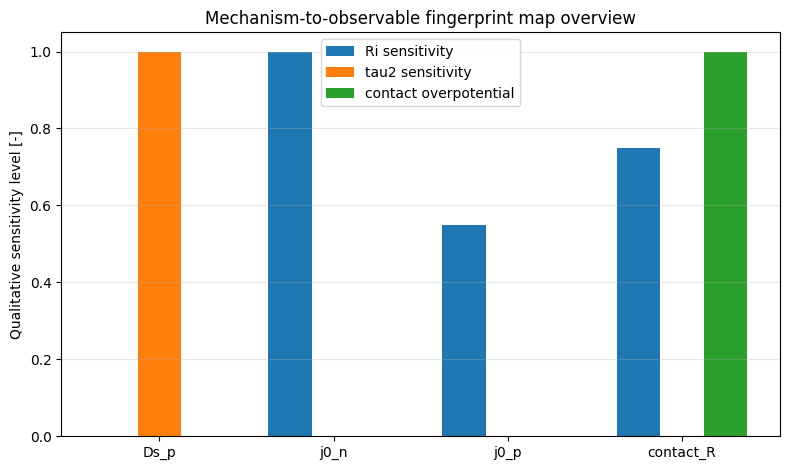

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/fingerprint_map_overview.png


In [6]:
# Cell 6 — Fingerprint map overview plot（机制指纹总览图）

overview_rows = [
    {"family": "Ds_p", "Ri_sensitivity": 0.0, "tau2_sensitivity": 1.0, "contact_sensitivity": 0.0},
    {"family": "j0_n", "Ri_sensitivity": 1.0, "tau2_sensitivity": 0.0, "contact_sensitivity": 0.0},
    {"family": "j0_p", "Ri_sensitivity": 0.55, "tau2_sensitivity": 0.0, "contact_sensitivity": 0.0},
    {"family": "contact_R", "Ri_sensitivity": 0.75, "tau2_sensitivity": 0.0, "contact_sensitivity": 1.0},
]

overview = pd.DataFrame(overview_rows)

fig, ax = plt.subplots(figsize=(8, 4.8))

x = np.arange(len(overview))
width = 0.25

ax.bar(x - width, overview["Ri_sensitivity"], width, label="Ri sensitivity")
ax.bar(x, overview["tau2_sensitivity"], width, label="tau2 sensitivity")
ax.bar(x + width, overview["contact_sensitivity"], width, label="contact overpotential")

ax.set_xticks(x)
ax.set_xticklabels(overview["family"])
ax.set_ylabel("Qualitative sensitivity level [-]")
ax.set_title("Mechanism-to-observable fingerprint map overview")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "fingerprint_map_overview.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

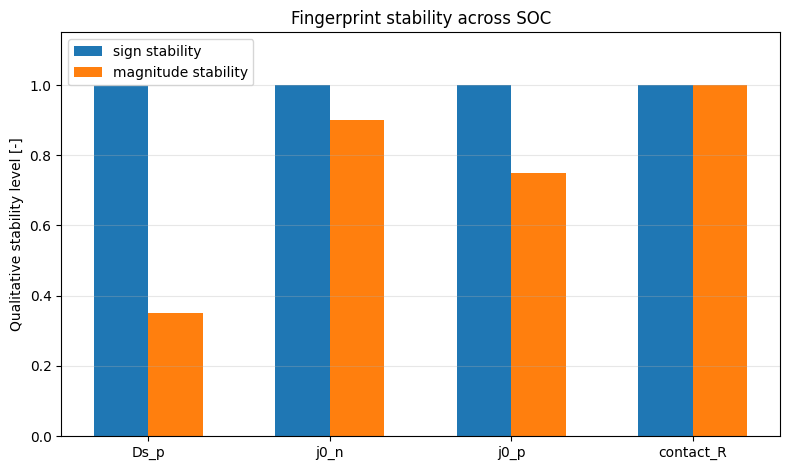

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/fingerprint_stability_summary.png


In [7]:
# Cell 7 — Fingerprint stability summary plot（跨 SOC 指纹稳定性总览图）

stability_plot_rows = [
    {"family": "Ds_p", "sign_stability": 1.0, "magnitude_stability": 0.35},
    {"family": "j0_n", "sign_stability": 1.0, "magnitude_stability": 0.9},
    {"family": "j0_p", "sign_stability": 1.0, "magnitude_stability": 0.75},
    {"family": "contact_R", "sign_stability": 1.0, "magnitude_stability": 1.0},
]

stability_plot = pd.DataFrame(stability_plot_rows)

fig, ax = plt.subplots(figsize=(8, 4.8))

x = np.arange(len(stability_plot))
width = 0.3

ax.bar(x - width / 2, stability_plot["sign_stability"], width, label="sign stability")
ax.bar(x + width / 2, stability_plot["magnitude_stability"], width, label="magnitude stability")

ax.set_xticks(x)
ax.set_xticklabels(stability_plot["family"])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Qualitative stability level [-]")
ax.set_title("Fingerprint stability across SOC")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "fingerprint_stability_summary.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)